# Background

The following may be helpful when reading or debugginfg this notebook:


### Standard Amino Acids
The FASTA data format represents each amino acid with a single character as follows:

| 1-Letter Code | 3-Letter Code | Amino Acid Name |
|---|---|---|
| A | Ala | Alanine |
| C | Cys | Cysteine |
| D | Asp | Aspartic acid |
| E | Glu | Glutamic acid |
| F | Phe | Phenylalanine |
| G | Gly | Glycine |
| H | His | Histidine |
| I | Ile | Isoleucine |
| K | Lys | Lysine |
| L | Leu | Leucine |
| M | Met | Methionine |
| N | Asn | Asparagine |
| P | Pro | Proline |
| Q | Gln | Glutamine |
| R | Arg | Arginine |
| S | Ser | Serine |
| T | Thr | Threonine |
| V | Val | Valine |
| W | Trp | Tryptophan |
| Y | Tyr | Tyrosine |

### Ambiguous & Special Characters
The FASTA format also uses the following abbreviations for ambiguous amino acid identification and special characters:

| 1-Letter Code | Description / Meaning |
|---|---|
| B | Aspartic acid (D) or Asparagine (N) |
| J | Leucine (L) or Isoleucine (I) |
| X | Unknown or any amino acid |
| Z | Glutamic acid (E) or Glutamine (Q) |
| * | Translation stop codon |
| - | Gap of missing or unsequenced amino acid |

# Environment Setup

In this section we're setting up the environment for the rest of the notebook.

In [33]:
# Core libraries
import pandas as pd
import numpy as np
import warnings
import random
import torch
import esm
import re

# File read / write
import pickle

# Machine Learning / Modeling
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (f1_score, roc_curve,
                             confusion_matrix, ConfusionMatrixDisplay, roc_auc_score,
                             average_precision_score, precision_recall_curve)

# Gradient boosting libraries

# Deep Learning
from tensorflow import keras
from tensorflow.keras import layers

# Statistical / other utilities

# Explainability

# Visualization
import matplotlib.pyplot as plt

# BioPython
from Bio import SeqIO

# Environment Settings
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
np.random.seed(42)
warnings.filterwarnings('ignore')

# Filepaths for source data files
path1 = '../data/raw/uniprotkb_proteome_UP000002311.fasta'
path2 = '../data/raw/BIOGRID-ORGANISM-Saccharomyces_cerevisiae_S288c-5.0.259.mitab.txt'

In [34]:
# New installations required for this project

#%pip install biopython
#pip install torch
#pip install safetensors==0.4.5
#pip install fair-esm

# Helper Functions

In this section we're defining some helper functions for use in the rest of the notebook.

In [35]:
def read_fasta(file_path):
    """Funtion to read the ID and Sequence info from the FASTA file"""
    sequences = {}
    current_id = None
    current_seq = []

    with open(file_path, "r") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue

            # Lines starting with '>' indicate a new sequence ID
            if line.startswith(">"):
                if current_id:
                    sequences[current_id] = "".join(current_seq)
                current_id = line[1:]  # Remove the '>' character
                current_seq = []
            else:
                current_seq.append(line)

        # Add the final sequence from the file
        if current_id:
            sequences[current_id] = "".join(current_seq)

    return sequences


def extract_locuslink(s):
    """Function to extract the Uniprot gene IDs from the Biogrid dataframe"""
    match = re.search(r'locuslink:([^|]+)', s)
    return match.group(1) if match else None


def get_interactors(bg, protein_id):
    """Function to extract interactions from Biogrid dataframe"""
    # Protein appears in column A
    a_partners = bg.loc[
        bg['Gene_A'] == protein_id,
        'Gene_B'
    ]

    # Protein appears in column B
    b_partners = bg.loc[
        bg['Gene_B'] == protein_id,
        'Gene_A'
    ]

    # Combine, deduplicate, and return as a list
    return pd.concat([a_partners, b_partners]).drop_duplicates().tolist()


def get_esm_embedding(model, sequence, batch_converter):
    """Function to create the embedding for a given protein"""
    batch_labels, batch_strs, batch_tokens = batch_converter([("P", sequence)])
    batch_tokens = batch_tokens.to(device)
    with torch.no_grad():
        results = model(batch_tokens, repr_layers=[last_layer], return_contacts=False)
    token_representations = results["representations"][last_layer]
    protein_representations = token_representations[0,1:-1,:].mean(dim=0).cpu().numpy()
    return protein_representations


def random_protein(length):
    """Function to generate a randome amino acid sequence of fixed length"""
    rand01 = ''.join(random.choices("ACDEFGHIKLMNPQRSTVWY", k=length))
    return rand01


def get_pairwise_features(embA, embB):
    """Function to create the pair-wise feature set for 2 embeddings"""
    pairwise = np.concatenate([embA, embB, np.abs(embA - embB), embA * embB])
    return pairwise

def create_balanced_dataset(interaction_matrix, embeddings, n=1000, random_state=42):
    """This functions returns a balanced dataset (equal numbers of interacting and non-interacting pairs) 
    of pairwise embeddings of specified size for training the NN
    """
    rng = np.random.default_rng(random_state)

    proteins = interaction_matrix.index.to_numpy()

    # Get upper-triangle indices, excluding diagonal
    i, j = np.triu_indices(len(proteins), k=1)

    # Get corresponding interaction values
    values = interaction_matrix.values[i, j]

    # Separate positive and negative pairs
    positive_idx = np.where(values == 1)[0]
    negative_idx = np.where(values == 0)[0]

    # Check that enough pairs exist
    if len(positive_idx) < n:
        raise ValueError(
            f"Only {len(positive_idx)} positive pairs available; "
            f"cannot sample {n}."
        )

    if len(negative_idx) < n:
        raise ValueError(
            f"Only {len(negative_idx)} negative pairs available; "
            f"cannot sample {n}."
        )

    # Randomly select n of each
    positive_sample = rng.choice(
        positive_idx, size=n, replace=False
    )

    negative_sample = rng.choice(
        negative_idx, size=n, replace=False
    )

    selected = np.concatenate([
        positive_sample,
        negative_sample
    ])

    # Shuffle positive and negative examples together
    rng.shuffle(selected)

    X = []
    y = []
    pairs = []

    for idx in selected:

        protein_a = proteins[i[idx]]
        protein_b = proteins[j[idx]]

        emb_a = embeddings[protein_a]
        emb_b = embeddings[protein_b]

        # Symmetric pair representation
        pair_embedding = np.concatenate([
            np.abs(emb_a - emb_b),
            emb_a * emb_b
        ]) # Could use alternate function "get_pairwise_features(emb1, emb2)" here

        X.append(pair_embedding)
        y.append(values[idx])
        pairs.append((protein_a, protein_b))

    return np.array(X), np.array(y), pairs

# Section 1 - Data Import

In this section we are importing amino acid sequences for all 6,067 amino acids in S. cerevisiae, and interaction data from BioGrid.

In [36]:
# Import dataset
# Print 3 First Rows
for i, record in enumerate(SeqIO.parse(path1, "fasta")):
    if i >= 3:
        break
    print(f"ID: {record.id}")
    print(f"Sequence: {record.seq}")
    print(f"Length: {len(record.seq)}\n")

ID: sp|A0A0B7P3V8|YP41B_YEAST
Sequence: MATPVRDETRNVIDDNISARIQSKVKTNDTVRQTPSSLRKVSIKDEQVKQYQRNLNRFKTILNGLKAEEEKLSETDDIQMLAEKLLKLGETIDKVENRIVDLVEKIQLLETNENNNILHEHIDATGTYYLFDTLTSTNKRFYPKDCVFDYRTNNVENIPILLNNFKKFIKKYQFDDVFENDIIEIDPRENEILCKIIKEGLGESLDIMNTNTTDIFRIIDGLKNKYRSLHGRDVRIRAWEKVLVDTTCRNSALLMNKLQKLVLMEKWIFSKCCQDCPNLKDYLQEAIMGTLHESLRNSVKQRLYNIPHNVGINHEEFLINTVIETVIDLSPIADDQIENSCMYCKSVFHCSINCKKKPNRELRPDSTNFSKTYYLQGAQRQQQLKSSAKEQKSWNKTQKKSNKVYNSKKLVIIDTGSGVNITNDKTLLHNYEDSNRSTRFFGIGKNSSVSVKGYGYIKIKNGHNNTDNKCLLTYYVPEEESTIISCYDLAKKTKMVLSRKYTRLGNKIIKIKTKIVNGVIHVKMNELIERPSDDSKINAIKPTSSPGFKLNKRSITLEDAHKRMGHTGIQQIENSIKHNHYEESLDLIKEPNEFWCQTCKISKATKRNHYTGSMNNHSTDHEPGSSWCMDIFGPVSSSNADTKRYMLIMVDNNTRYCMTSTHFNKNAETILAQIRKNIQYVETQFDRKVREINSDRGTEFTNDQIEEYFISKGIHHILTSTQDHAANGRAERYIRTIVTDATTLLRQSNLRVKFWEYAVTSATNIRNCLEHKSTGKLPLKAISRQPVTVRLMSFLPFGEKGIIWNHNHKKLKPSGLPSIILCKDPNSYGYKFFIPSKNKIVTSDNYTIPNYTMDGRVRNTQNIYKSHQFSSHNDNEEDQIETVTNLCEALENYEDDNKPITRLEDLFTEEELSQIDSNAKYPSPSNNLEGDLDYVFSDVEESGDYDVESELSTTNTSIST

In [37]:
# Create the protein-sequence dictionary and a dictionary of protein residue length
sequence_dictionary = {}
length_dictionary = {}
fasta_data = read_fasta(path1)

for seq_id, sequence, in fasta_data.items():
    match = re.search(r'GN=(\S+)', seq_id)
    if match:
        gene_name = match.group(1)
        sequence_dictionary[gene_name] = sequence
        length_dictionary[gene_name] = len(sequence)

# Create a list of all proteins for future use
gene_list = list(sequence_dictionary.keys())

In [38]:
# Inspect the results
print(gene_list[:5])
print(len(gene_list))

['TY4B-P', 'STE2', 'CET1', 'FOB1', 'RPS9A']
6067


In [39]:
# Check if a particular gene is included in the Uniprot data
if 'CDC73' in gene_list:
    print("Item found!")

Item found!


Here we are importing the interaction data from BioGrid.

In [40]:
# Now extract the Biogrid data and create the Biogrid dataframe
bg = pd.read_csv(path2,
    sep="\t",
    header=None,
    dtype=str
)

print(bg.shape)

# Reset the row and column indices
bg.columns = bg.iloc[0]
bg = bg[1:]
bg.columns.name = None
bg = bg.reset_index(drop=True)

# Inspect the results
print(bg.shape)

(885690, 15)
(885689, 15)


In [41]:
# Check the Biogrid data at a particular dataframe location
print(bg.at[1, 'Alt IDs Interactor A'])

biogrid:34272|entrez gene/locuslink:CTR9|entrez gene/locuslink:YOL145C|uniprot/swiss-prot:P89105|refseq:NP_014496


In [42]:
# Extract the interactor A and B genes and create a new column for each
bg['Gene_A'] = bg['Alt IDs Interactor A'].apply(extract_locuslink)
bg['Gene_B'] = bg['Alt IDs Interactor B'].apply(extract_locuslink)

# Inspect the results
bg.head()

,#ID Interactor A,ID Interactor B,Alt IDs Interactor A,Alt IDs Interactor B,Aliases Interactor A,Aliases Interactor B,Interaction Detection Method,Publication 1st Author,Publication Identifiers,Taxid Interactor A,Taxid Interactor B,Interaction Types,Source Database,Interaction Identifiers,Confidence Values,Gene_A,Gene_B
0,entrez gene/locuslink:851136,entrez gene/locuslink:854020,biogrid:31676|entrez gene/locuslink:CDC73|entr...,biogrid:34272|entrez gene/locuslink:CTR9|entre...,entrez gene/locuslink:L000002792(gene name syn...,entrez gene/locuslink:CDP1(gene name synonym)|...,"psi-mi:""MI:0004""(affinity chromatography techn...",Krogan NJ (2004),pubmed:14759368,taxid:559292,taxid:559292,"psi-mi:""MI:0915""(physical association)","psi-mi:""MI:0463""(biogrid)",biogrid:68770,-,CDC73,CTR9
1,entrez gene/locuslink:854020,entrez gene/locuslink:851136,biogrid:34272|entrez gene/locuslink:CTR9|entre...,biogrid:31676|entrez gene/locuslink:CDC73|entr...,entrez gene/locuslink:CDP1(gene name synonym)|...,entrez gene/locuslink:L000002792(gene name syn...,"psi-mi:""MI:0004""(affinity chromatography techn...",Krogan NJ (2004),pubmed:14759368,taxid:559292,taxid:559292,"psi-mi:""MI:0915""(physical association)","psi-mi:""MI:0463""(biogrid)",biogrid:68771,-,CTR9,CDC73
2,entrez gene/locuslink:851136,entrez gene/locuslink:854290,biogrid:31676|entrez gene/locuslink:CDC73|entr...,biogrid:34518|entrez gene/locuslink:LEO1|entre...,entrez gene/locuslink:L000002792(gene name syn...,entrez gene/locuslink:L000000936(gene name syn...,"psi-mi:""MI:0004""(affinity chromatography techn...",Krogan NJ (2004),pubmed:14759368,taxid:559292,taxid:559292,"psi-mi:""MI:0915""(physical association)","psi-mi:""MI:0463""(biogrid)",biogrid:68774,-,CDC73,LEO1
3,entrez gene/locuslink:854290,entrez gene/locuslink:851136,biogrid:34518|entrez gene/locuslink:LEO1|entre...,biogrid:31676|entrez gene/locuslink:CDC73|entr...,entrez gene/locuslink:L000000936(gene name syn...,entrez gene/locuslink:L000002792(gene name syn...,"psi-mi:""MI:0004""(affinity chromatography techn...",Krogan NJ (2004),pubmed:14759368,taxid:559292,taxid:559292,"psi-mi:""MI:0915""(physical association)","psi-mi:""MI:0463""(biogrid)",biogrid:68775,-,LEO1,CDC73
4,entrez gene/locuslink:851136,entrez gene/locuslink:852582,biogrid:31676|entrez gene/locuslink:CDC73|entr...,biogrid:32973|entrez gene/locuslink:PAF1|entre...,entrez gene/locuslink:L000002792(gene name syn...,entrez gene/locuslink:L000002621(gene name syn...,"psi-mi:""MI:0004""(affinity chromatography techn...",Krogan NJ (2004),pubmed:14759368,taxid:559292,taxid:559292,"psi-mi:""MI:0915""(physical association)","psi-mi:""MI:0463""(biogrid)",biogrid:68778,-,CDC73,PAF1


This cell takes quite a while to run locally; therefore writing the results to file for future use.

In [43]:
# CELL_TAKE_TIME
# Comment out the following code if you have already created the interactions.pkl file and don't want to re-run this step.
# Now we make the interaction dictionary and write to file for future use
# ia_dic = {}

# # Iterate through each gene and extract interactions
# for gene in gene_list:
#     interactors = get_interactors(bg, gene)
#     ia_dic[gene] = interactors

# # Write the interaction dictionary to file
# with open('../data/processed/interactions.pkl', 'wb') as file:
#     pickle.dump(ia_dic, file)

In [44]:
# Read the interaction dictionary from the binary file
with open('../data/processed/interactions.pkl', 'rb') as file:
    interaction_dictionary = pickle.load(file)

In [45]:
# Inspect the results (first 5 keys, first 5 values each)
{k: v[:5] for k, v in list(interaction_dictionary.items())[:5]}

{'TY4B-P': [],
 'STE2': ['STE2', 'STE4', 'GPA1', 'STE5', 'AXL1'],
 'CET1': ['TUP1', 'CEG1', 'CET1', 'SPT4', 'SPT5'],
 'FOB1': ['NET1', 'SIR2', 'CDC14', 'FOB1', 'NSI1'],
 'RPS9A': ['MPP10', 'RPS9B', 'TAE2', 'RTC6', 'snR30']}

# Section 2 - Data Cleaning & Pre-processing

In this section we perform some data cleaning and pre-processing operations. 

In [46]:
#First, we need to make sure we have sequence and interaction data for all proteins.

# Find entries in the interaction dictionary that are empty
empty_keys = [key for key, value in interaction_dictionary.items() if not value]
print('Number of empty entries in the interaction dictionary:')
print(len(empty_keys))

# Remove them from the sequence and interation dictionaries
for key in empty_keys:
    sequence_dictionary.pop(key, None)
    length_dictionary.pop(key, None)
    interaction_dictionary.pop(key, None)

print('')
print('Number of proteins for which he have sequence AND interaction data:')
print(len(sequence_dictionary))

new_gene_list = list(sequence_dictionary.keys())

Number of empty entries in the interaction dictionary:
397

Number of proteins for which he have sequence AND interaction data:
5670


In [47]:
# Next we need to remove any interactors for which we don't have sequence data
interaction_dictionary_filtered = {
    protein: [p for p in partners if p in new_gene_list]
    for protein, partners in interaction_dictionary.items()
}

In [48]:
# Inspect the results (first 5 keys, first 5 values each)
{k: v[:5] for k, v in list(interaction_dictionary_filtered.items())[:5]}

{'STE2': ['STE2', 'STE4', 'GPA1', 'STE5', 'AXL1'],
 'CET1': ['TUP1', 'CEG1', 'CET1', 'SPT4', 'SPT5'],
 'FOB1': ['NET1', 'SIR2', 'CDC14', 'FOB1', 'NSI1'],
 'RPS9A': ['MPP10', 'RPS9B', 'RTC6', 'MOB2', 'HIR1'],
 'COQ4': ['NDI1', 'NDE1', 'COQ9', 'COQ8', 'GLE1']}

In [49]:
# Finally we create the overall interaction matrix using the interaction dictionary - a square
# matrix 5670 x 5670 with 1's indicating interactions, 0's indicating no interaction.
# Note that this will by a symmetric matrix.

# We will call this the 'Master Interaction Matrix' or MIM
MIM = pd.DataFrame(0, index=new_gene_list, columns=new_gene_list)

for protein, partners in interaction_dictionary_filtered.items():
    MIM.loc[protein, partners] = 1

In [50]:
# Perform some checks to make sure MIM is setup correctly, check sparsity
row = 'CET1'
column = 'STE2'

print(f'MIM entry at {row}, {column}:')
print(MIM.loc[row, column])
print('')

# See how sparse MIM
count_ones = np.count_nonzero(MIM)
print('Number of non-zero entries in the MIM:')
print(count_ones)
print('')

print('Total number of entries in the MIM:')
num_entries = 5670*5670
print(num_entries)
print('')

print('Sparsity of the MIM:')
print(count_ones/num_entries)

MIM entry at CET1, STE2:
0

Number of non-zero entries in the MIM:
1220487

Total number of entries in the MIM:
32148900

Sparsity of the MIM:
0.037963569515597734


# Section 3 - Create Embeddings

In this section we are creating the embeddings for all the proteins for whcih we have sequence AND interaction data. We will then perform some checks to make sure the embeddings are behaving as expected, by comparing the cosine similarity between various embeddings.

In [51]:
# Load a pre-trained ESM embedding model for use in the create emmbedding function

# NOTE: The code in this cell was derived from the following ESM2-Tutorial repository:
# https://github.com/ProteinVision/ESM2-Tutorial/blob/main/ESM2.ipynb

# Utilize GPU resources if available, otherwise default to CPU
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using device {device} for data processing.')

# Load the model producing 1280-dim embeddings
model, alphabet = esm.pretrained.esm2_t33_650M_UR50D()
last_layer = len(model.layers)
batch_converter = alphabet.get_batch_converter()
model.eval()
model.to(device)

# Print the token alphabet (first 5 items)
dict(list(alphabet.to_dict().items())[:5])

Using device cpu for data processing.


{'<cls>': 0, '<pad>': 1, '<eos>': 2, '<unk>': 3, 'L': 4}

In [52]:
# Perform some basic checks of the embedding

# Define a sequence and confirm the embedding has the right dimensionality
seq1 = 'MSDAAPSLSNLFYDPTYNPGQSTINYTSIYGNGSTITFDELQGLVNSTVTQAIMFGVRCGAAALTLIVMWMTSRSRKTPIFIINQVSLFLIILHSALYFKYLLSNYSSVTYALTGFPQFISRGDVHVYGATNIIQVLLVASIETSLVFQIKVIFTGDNFKRIGLMLTSISFTLGIATVTMYFVSAVKGMIVTYNDVSATQDKYFNASTILLASSINFMSFVLVVKLILAIRSRRFLGLKQFDSFHILLIMSCQSLLVPSIIFILAYSLKPNQGTDVLTTVATLLAVLSLPLSSMWATAANNASKTNTITSDFTTSTDRFYPGTLSSFQTDSINNDAKSSLRSRLYDLYPRRKETTSDKHSERTFVSETADDIEKNQFYQLPTPTSSKNTRIGPFADASYKEGEVEPVDMYTPDTAADEEARKFWTEDNNNL'
emb1 = get_esm_embedding(model, seq1, batch_converter)

# Confirm shape, content
print('Length of sequence embedding:')
print(len(emb1))
print('')
print('Values in embedding:')
print(emb1)

Length of sequence embedding:
1280

Values in embedding:
[-0.04797408 -0.00718806  0.02167165 ... -0.14549576  0.04699722
  0.07034333]


In [53]:
# Perform some more advanced checks

# Define two similar proteins - human alpha globin (HAG) and human beta globin (HBG)
HAG = "MVLSPADKTNVKAAWGKVGAHAGEYGAEALERMFLSFPTTKTYFPHFDLSHGSAQVKGHGKKVADALTNAVAHVDDMPNALSALSDLHAHKLRVDPVNFKLLSHCLLVTLAAHLPAEFTPAVHASLDKFLASVSTVLTSKYR"
HBG = "MVHLTPEEKSAVTALWGKVNVDEVGGEALGRLLVVYPWTQRFFESFGDLSTPDAVMGNPKVKAHGKKVLGAFSDGLAHLDNLKGTFATLSELHCDKLHVDPENFRLLGNVLVCVLAHHFGKEFTPPVQAAYQKVVAGVANALAHKYH"

# Pick a random S. cerivisiae protein
CDC73 = sequence_dictionary['CDC73']

# Create 2 random proteins of similar length
rand1 = random_protein(150)
rand2 = random_protein(150)

# Check the cosine similarity between the two
alpha = get_esm_embedding(model, HAG, batch_converter)
beta = get_esm_embedding(model, HBG, batch_converter)
delta = get_esm_embedding(model, CDC73, batch_converter)
gamma1 = get_esm_embedding(model, rand1, batch_converter)
gamma2 = get_esm_embedding(model, rand2, batch_converter)

In [54]:
# Calculate the cosine similarity betwen HAG and HBG
print("Cosine similarity between human alpha globin (HAG) and human beta globin (HBG) embeddings:")
a = alpha
b = beta
similarity = np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b))
print(similarity)
print('')

# Calculate the cosine similarity between HAG and a protein sequence from S. cerivisiae
print("Cosine similarity between human alpha globin (HAG) and CDC73:")
a = alpha
b = delta
similarity = np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b))
print(similarity)
print('')

# Calculate the cosine similarity between HAG and a random protein sequence
print("Cosine similarity between human alpha globin (HAG) and a random protein sequence:")
a = alpha
b = gamma1
similarity = np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b))
print(similarity)
print('')

# Calculate the cosine similarity between HAG and the other random protein sequence
print("Cosine similarity between human alpha globin (HAG) and another random protein sequence:")
a = alpha
b = gamma2
similarity = np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b))
print(similarity)

Cosine similarity between human alpha globin (HAG) and human beta globin (HBG) embeddings:
0.95145655

Cosine similarity between human alpha globin (HAG) and CDC73:
0.8252415

Cosine similarity between human alpha globin (HAG) and a random protein sequence:
0.7092436

Cosine similarity between human alpha globin (HAG) and another random protein sequence:
0.65462035


This cell takes quite a while to run locally; therefore writing the results to file for future use.

In [55]:
# CELL_TAKE_TIME
# Comment out the following code if you have already created the embeddings.pkl file and don't want to re-run this step.
# Creat a dictionary of embeddings for all proteins, and write to file
# embedding_dict = {}

# # Loop through each protein in the set
# for gene in new_gene_list:
#     sequence = sequence_dictionary[gene]
#     embedding = get_esm_embedding(model, sequence, batch_converter)
#     embedding_dict[gene] = embedding

# # Write the embeddings dictionary to file
# with open('../data/processed/embeddings.pkl', 'wb') as file:
#     pickle.dump(embedding_dict, file)

In [56]:
# Read the embedding dictionary from the binary file
with open('../data/processed/embeddings.pkl', 'rb') as file:
    embedding_dict = pickle.load(file)

In [57]:
# Inspect the results (first 5 keys, first 5 values each)
{k: v[:5] for k, v in list(embedding_dict.items())[:5]}

{'STE2': array([-0.04797408, -0.00718806,  0.02167165,  0.06603702, -0.03343712],
       dtype=float32),
 'CET1': array([-0.00223311, -0.01582935,  0.04741028,  0.01531323,  0.0022517 ],
       dtype=float32),
 'FOB1': array([ 0.01796917, -0.07855558,  0.03557299,  0.01860837,  0.02187089],
       dtype=float32),
 'RPS9A': array([ 0.01126087, -0.01193911,  0.04757049,  0.01326585, -0.06809363],
       dtype=float32),
 'COQ4': array([-0.0266132 ,  0.03327498, -0.02508251, -0.03675416,  0.01357298],
       dtype=float32)}

In [58]:
# Create a second embedding model using the smaller pre-trained ESM2

# NOTE: The code in this cell was derived from the following ESM2-Tutorial repository:
# https://github.com/ProteinVision/ESM2-Tutorial/blob/main/ESM2.ipynb

# Utilize GPU resources if available, otherwise default to CPU
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using device {device} for data processing.')

# Load the model producing 640-dim embeddings
model_small, alphabet_small = esm.pretrained.esm2_t6_8M_UR50D()
last_layer = len(model_small.layers)
batch_converter = alphabet_small.get_batch_converter()
model_small.eval()
model_small.to(device)

Using device cpu for data processing.


ESM2(
  (embed_tokens): Embedding(33, 320, padding_idx=1)
  (layers): ModuleList(
    (0-5): 6 x TransformerLayer(
      (self_attn): MultiheadAttention(
        (k_proj): Linear(in_features=320, out_features=320, bias=True)
        (v_proj): Linear(in_features=320, out_features=320, bias=True)
        (q_proj): Linear(in_features=320, out_features=320, bias=True)
        (out_proj): Linear(in_features=320, out_features=320, bias=True)
        (rot_emb): RotaryEmbedding()
      )
      (self_attn_layer_norm): LayerNorm((320,), eps=1e-05, elementwise_affine=True)
      (fc1): Linear(in_features=320, out_features=1280, bias=True)
      (fc2): Linear(in_features=1280, out_features=320, bias=True)
      (final_layer_norm): LayerNorm((320,), eps=1e-05, elementwise_affine=True)
    )
  )
  (contact_head): ContactPredictionHead(
    (regression): Linear(in_features=120, out_features=1, bias=True)
    (activation): Sigmoid()
  )
  (emb_layer_norm_after): LayerNorm((320,), eps=1e-05, elementwis

This cell takes quite a while to run locally; therefore writing the results to file for future use.

In [59]:
# CELL_TAKE_TIME
# Comment out the following code if you have already created the embeddings_small.pkl file and don't want to re-run this step.
# Creat a dictionary of embeddings for all proteins, and write to file
# embedding_dict_small = {}

# # Loop through each protein in the set
# for gene in new_gene_list:
#     sequence = sequence_dictionary[gene]
#     embedding = get_esm_embedding(model_small, sequence, batch_converter)
#     embedding_dict_small[gene] = embedding

# # Write the embeddings dictionary to file
# with open('../data/processed/embeddings_small.pkl', 'wb') as file:
#     pickle.dump(embedding_dict_small, file)

In [60]:
# Read the embedding dictionary from the binary file
with open('../data/processed/embeddings_small.pkl', 'rb') as file:
    embedding_dict_small = pickle.load(file)

# Section 3 - Train the Model

In this section we train a basic feed-forward multi-layer perceptron (MLP).

In [61]:
# First we need to create a test/train split
train_proteins, test_proteins = train_test_split(
    new_gene_list,
    test_size=0.20,   #Train on 80% of the data, test on the other 20%
    random_state=42
)

# Now form test and train interaction matrices
MIM_train = MIM.loc[train_proteins, train_proteins]
MIM_test = MIM.loc[test_proteins, test_proteins]

In [62]:
# Create test and train dataframes
X_train, y_train, train_pairs = create_balanced_dataset(
    MIM_train,
    embedding_dict,
    n=100000,       # Number of positive and negative interactions to pull from the training interaction matrix
    random_state=42
)

X_test, y_test, train_pairs = create_balanced_dataset(
    MIM_test,
    embedding_dict,
    n=10000,        # Number of positive and negative interactions to pull from the test interaction matrix
    random_state=42
)

# Scale the train and test sets
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [63]:
# Define a simple neural network to start with
model = keras.Sequential([
    layers.Input(shape=(X_train.shape[1],)),

    layers.Dense(512, activation='relu'),
    layers.Dropout(0.3),

    layers.Dense(256, activation='relu'),
    layers.Dropout(0.3),

    layers.Dense(64, activation='relu'),

    layers.Dense(1, activation='sigmoid')
])

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        keras.metrics.AUC(name='auc'),
        keras.metrics.Precision(name='precision'),
        keras.metrics.Recall(name='recall')
    ]
)

# Inspect the results
print(model.summary())

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 512)            │     1,311,232 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,459,073 (5.57 MB)

 Trainable params: 1,459,073 (5.57 MB)

 Non-trainable params: 0 (0.00 B)

None


In [64]:
# CELL_TAKE_TIME
# Comment out the following code if you have already trained the model and don't want to re-run this step.
# Train the simple neural network
# history = model.fit(
#     X_train_scaled,
#     y_train,
#     validation_split=0.2,
#     epochs=100,
#     batch_size=32,
#     verbose=1
# )
# # Save it for future use
# model.save('../data/processed/ppi_esm2_model.keras')

Here we are training a second model with the same architecture as the original using the reduced sized embeddings.

In [65]:
# Create test and train dataframes
X_train_small, y_train_small, train_pairs = create_balanced_dataset(
    MIM_train,
    embedding_dict_small,
    n=100000,       # Number of positive and negative interactions to pull from the training interaction matrix
    random_state=42
)

X_test_small, y_test_small, train_pairs = create_balanced_dataset(
    MIM_test,
    embedding_dict_small,
    n=10000,        # Number of positive and negative interactions to pull from the test interaction matrix
    random_state=42
)

# Scale the train and test sets
scaler = StandardScaler()

X_train_scaled_small = scaler.fit_transform(X_train_small)
X_test_scaled_small = scaler.transform(X_test_small)

In [66]:
# debug
print(X_train_scaled_small.shape)
print(X_train_small.shape)
print(X_train_small[0].shape)

(200000, 640)
(200000, 640)
(640,)


In [67]:
# Define a simple neural network to start with
model_small = keras.Sequential([
    layers.Input(shape=(X_train_small.shape[1],)),

    layers.Dense(256, activation='relu'),
    layers.Dropout(0.3),

    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),

    layers.Dense(32, activation='relu'),

    layers.Dense(1, activation='sigmoid')
])

model_small.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        keras.metrics.AUC(name='auc'),
        keras.metrics.Precision(name='precision'),
        keras.metrics.Recall(name='recall')
    ]
)

# Inspect the results
print(model_small.summary())

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                 │ (None, 256)            │       164,096 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 201,153 (785.75 KB)

 Trainable params: 201,153 (785.75 KB)

 Non-trainable params: 0 (0.00 B)

None


In [68]:
# CELL_TAKE_TIME
# Comment out the following code if you have already trained the model and don't want to re-run this step.
# Train the simple neural network
# history = model_small.fit(
#     X_train_scaled_small,
#     y_train_small,
#     validation_split=0.2,
#     epochs=100,
#     batch_size=32,
#     verbose=1
# )
# # Save it for future use
# model_small.save('../data/processed/ppi_esm2_model_small.keras')

# Section 4 - Evaluate the Models

In this section we are evaluating the models, creating standard evaluation metrics for binary classifiers, and comparing the results models trained using 2 different pre-trained embedding models.

In [69]:
# Re-load the previously trained models (as opposed to re-training them each time the notebook runs)
model1 = keras.models.load_model('../data/processed/ppi_esm2_model_no_scaling.keras')
model2 = keras.models.load_model('../data/processed/ppi_esm2_model.keras')
model_small = keras.models.load_model('../data/processed/ppi_esm2_model_small.keras')

### Evaluate the first model trained without scaling the embedding vectors

In [70]:
# Evaluate the model (1280-dimensional embedding, no scaling)
results = model1.evaluate(
    X_test,
    y_test,
    verbose=0
)

for name, value in zip(model1.metrics_names, results):
    print(f"{name}: {value:.4f}")

results1 = model1.evaluate(X_test, y_test, verbose=0, return_dict=True)

loss: 250.9064
compile_metrics: 0.5002


In [71]:
y_prob1 = model1.predict(X_test).ravel()

roc_auc1 = roc_auc_score(y_test, y_prob1)
APS1 = average_precision_score(y_test, y_prob1)

print('ROC-AUC:', roc_auc1)
print('PR-AUC:', APS1)

625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
ROC-AUC: 0.5006
PR-AUC: 0.5005999999999999


In [72]:
y_pred_labels1 = (y_prob1 >= 0.5).astype(int)

f1_1 = f1_score(y_test, y_pred_labels1)

print('f1 Score:', f1_1)

f1 Score: 0.0007996801279488205


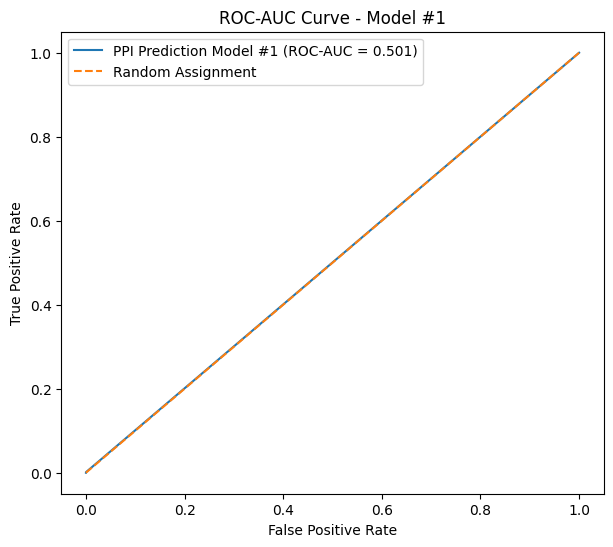

In [73]:
# Calculate ROC curve (without scaling)
fpr, tpr, thresholds = roc_curve(y_test, y_prob1)

# Calculate AUROC
auc = roc_auc_score(y_test, y_prob1)

# Plot
plt.figure(figsize=(7, 6))

plt.plot(fpr, tpr, label=f'PPI Prediction Model #1 (ROC-AUC = {auc:.3f})')

# Random classifier
plt.plot([0, 1], [0, 1], linestyle='--', label='Random Assignment')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-AUC Curve - Model #1')
plt.legend()
plt.show()

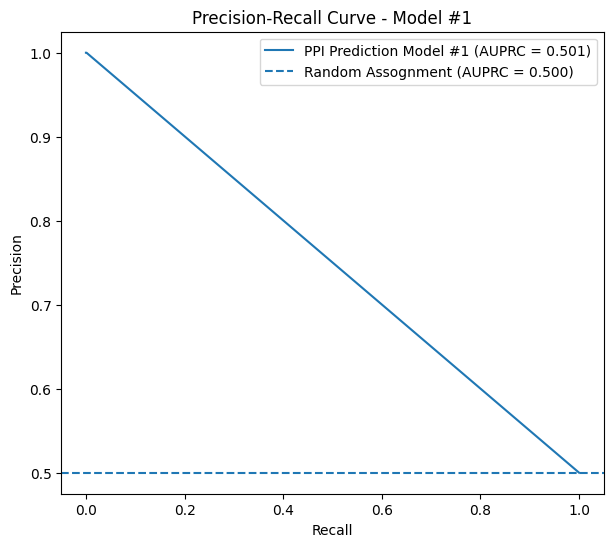

In [74]:
# Calculate precision-recall curve (without scaling)
precision, recall, thresholds = precision_recall_curve(y_test, y_prob1)

# Calculate AUPRC
auprc = average_precision_score(y_test, y_prob1)

# Plot
plt.figure(figsize=(7, 6))

plt.plot(
    recall,
    precision,
    label=f'PPI Prediction Model #1 (AUPRC = {auprc:.3f})'
)

# Baseline for a balanced test set
baseline = y_test.mean()
plt.axhline(
    baseline,
    linestyle='--',
    label=f'Random Assognment (AUPRC = {baseline:.3f})'
)

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve - Model #1')
plt.legend()
plt.show()

In [75]:
thresholds = np.arange(0.01, 1.00, 0.01)

f1_scores = []

for threshold in thresholds:
    y_pred1 = (y_prob1 >= threshold).astype(int)
    f1_scores.append(f1_score(y_test, y_pred1))

best_idx = np.argmax(f1_scores)

best_threshold = thresholds[best_idx]
best_f1_1 = f1_scores[best_idx]

print("Best threshold:", best_threshold)
print("Best F1:", best_f1_1)

Best threshold: 0.01
Best F1: 0.0007996801279488205


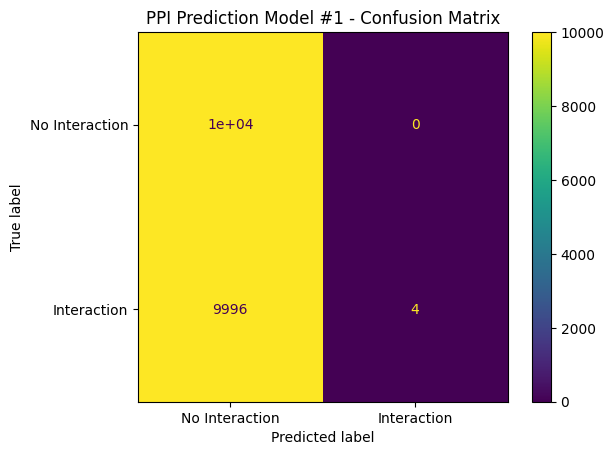

In [76]:
# Create a confusion matrix
# Convert probabilities to 0/1 predictions
y_pred1 = (y_prob1 >= 0.5).astype(int)

# Create confusion matrix
cm = confusion_matrix(y_test, y_pred1)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['No Interaction', 'Interaction']
)

disp.plot()
plt.title('PPI Prediction Model #1 - Confusion Matrix')
plt.show()

### Now we evaluate the model trained with scled embedding vectors

In [77]:
# Evaluate the model (1280-dimensional embedding, with scaling)
results = model2.evaluate(
    X_test_scaled,
    y_test,
    verbose=0
)

for name, value in zip(model2.metrics_names, results):
    print(f"{name}: {value:.4f}")

results2 = model2.evaluate(X_test_scaled, y_test, verbose=0, return_dict=True)

print(results2)

loss: 7033868288.0000
compile_metrics: 0.5968
{'accuracy': 0.596750020980835, 'auc': 0.596750020980835, 'loss': 7033868288.0, 'precision': 0.5744746327400208, 'recall': 0.7462999820709229}


In [78]:
y_prob2 = model2.predict(X_test_scaled).ravel()

roc_auc2 = roc_auc_score(y_test, y_prob2)
APS2 = average_precision_score(y_test, y_prob2)

print('ROC-AUC:', roc_auc2)
print('PR-AUC:', APS2)

625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
ROC-AUC: 0.59675
PR-AUC: 0.5555804210607342


In [79]:
y_pred_labels2 = (y_prob2 >= 0.5).astype(int)

f1_2 = f1_score(y_test, y_pred_labels2)

print('f1 Score:', f1_2)

f1 Score: 0.649210560654169


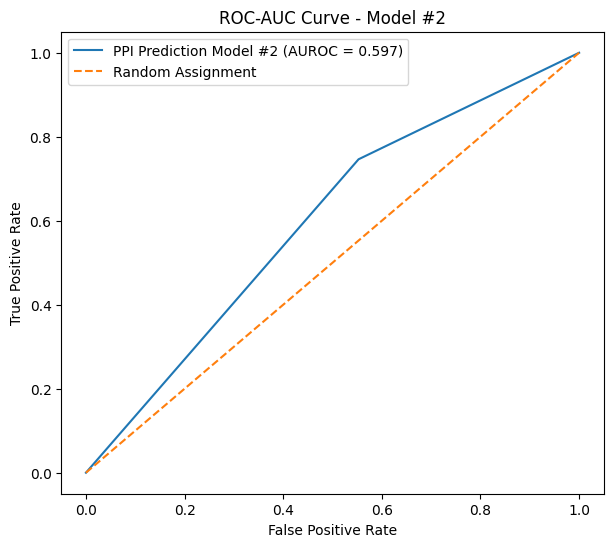

In [80]:
# Calculate ROC curve (with scaling)
fpr, tpr, thresholds = roc_curve(y_test, y_prob2)

# Calculate AUROC
auc = roc_auc_score(y_test, y_prob2)

# Plot
plt.figure(figsize=(7, 6))

plt.plot(fpr, tpr, label=f'PPI Prediction Model #2 (AUROC = {auc:.3f})')

# Random classifier
plt.plot([0, 1], [0, 1], linestyle='--', label='Random Assignment')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-AUC Curve - Model #2')
plt.legend()
plt.show()

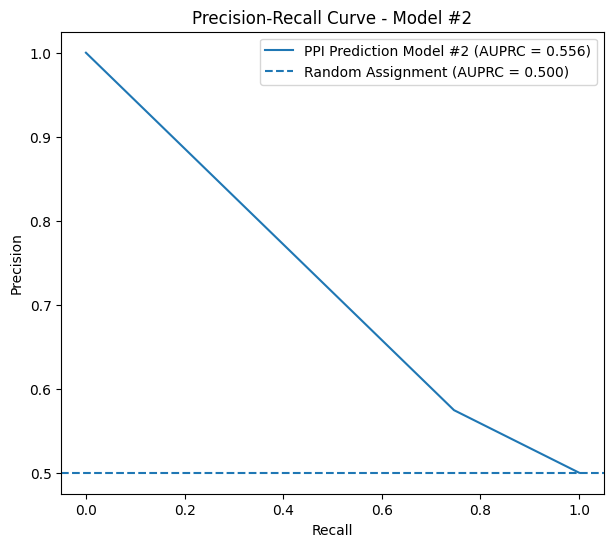

In [81]:
# Calculate precision-recall curve (with scaling)
precision, recall, thresholds = precision_recall_curve(y_test, y_prob2)

# Calculate AUPRC
auprc = average_precision_score(y_test, y_prob2)

# Plot
plt.figure(figsize=(7, 6))

plt.plot(
    recall,
    precision,
    label=f'PPI Prediction Model #2 (AUPRC = {auprc:.3f})'
)

# Baseline for a balanced test set
baseline = y_test.mean()
plt.axhline(
    baseline,
    linestyle='--',
    label=f'Random Assignment (AUPRC = {baseline:.3f})'
)

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve - Model #2')
plt.legend()
plt.show()

In [82]:
thresholds = np.arange(0.01, 1.00, 0.01)

f1_scores = []

for threshold in thresholds:
    y_pred = (y_prob2 >= threshold).astype(int)
    f1_scores.append(f1_score(y_test, y_pred))

best_idx = np.argmax(f1_scores)

best_threshold = thresholds[best_idx]
best_f1_2 = f1_scores[best_idx]

print('Best threshold:', best_threshold)
print('Best F1:', best_f1_2)

Best threshold: 0.01
Best F1: 0.649210560654169


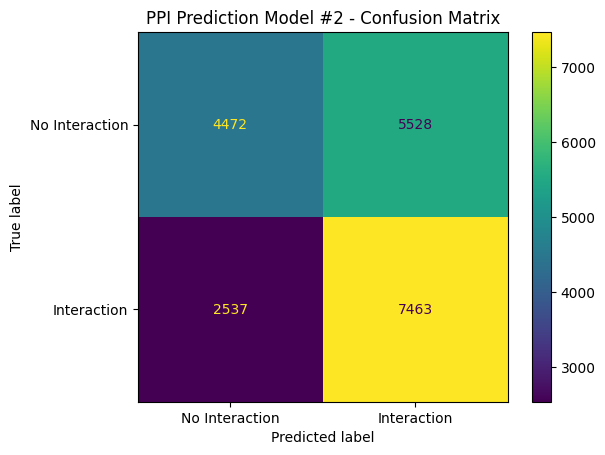

In [83]:
# Create a confusion matrix
# Convert probabilities to 0/1 predictions
y_pred = (y_prob2 >= 0.5).astype(int)

# Create confusion matrix
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['No Interaction', 'Interaction']
)

disp.plot()
plt.title('PPI Prediction Model #2 - Confusion Matrix')
plt.show()

### Finally, we evaluate the model trained using the smaller embeddings (and scaled data)

In [84]:
# Evaluate the model (640-dimensional embedding, with scaling)
results_small = model_small.evaluate(
    X_test_scaled_small,
    y_test_small,
    verbose=0
)

for name, value in zip(model_small.metrics_names, results_small):
    print(f"{name}: {value:.4f}")

results_small = model_small.evaluate(X_test_scaled_small, y_test_small, verbose=0, return_dict=True)

print(results_small)

loss: 98013088.0000
compile_metrics: 0.5871
{'accuracy': 0.587149977684021, 'auc': 0.587149977684021, 'loss': 98013088.0, 'precision': 0.5616467595100403, 'recall': 0.7940000295639038}


In [85]:
y_prob_small = model_small.predict(X_test_scaled_small).ravel()

roc_auc_small = roc_auc_score(y_test, y_prob_small)
APS_small = average_precision_score(y_test, y_prob_small)

print('ROC-AUC:', roc_auc_small)
print('PR-AUC:', APS_small)

625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 996us/step
ROC-AUC: 0.58715
PR-AUC: 0.5489475136167503


In [86]:
y_pred_labels_small = (y_prob_small >= 0.5).astype(int)

f1_small = f1_score(y_test_small, y_pred_labels_small)

print('f1 Score:', f1_small)

f1 Score: 0.6579110908563616


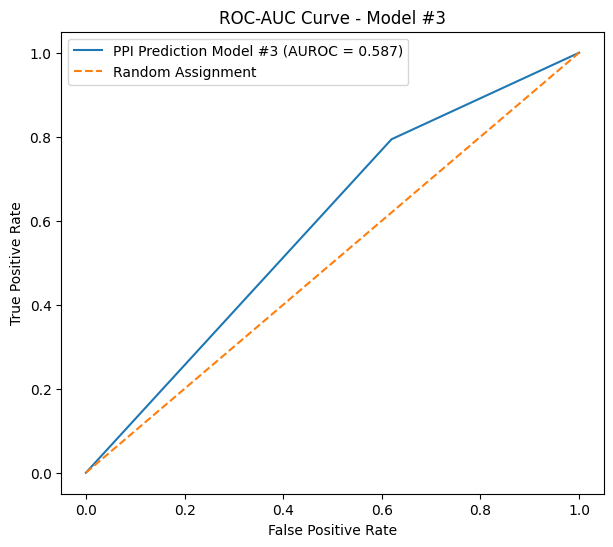

In [87]:
# Calculate ROC curve (with scaling)
fpr, tpr, thresholds = roc_curve(y_test_small, y_prob_small)

# Calculate AUROC
auc = roc_auc_score(y_test, y_prob_small)

# Plot
plt.figure(figsize=(7, 6))

plt.plot(fpr, tpr, label=f'PPI Prediction Model #3 (AUROC = {auc:.3f})')

# Random classifier
plt.plot([0, 1], [0, 1], linestyle='--', label='Random Assignment')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-AUC Curve - Model #3')
plt.legend()
plt.show()

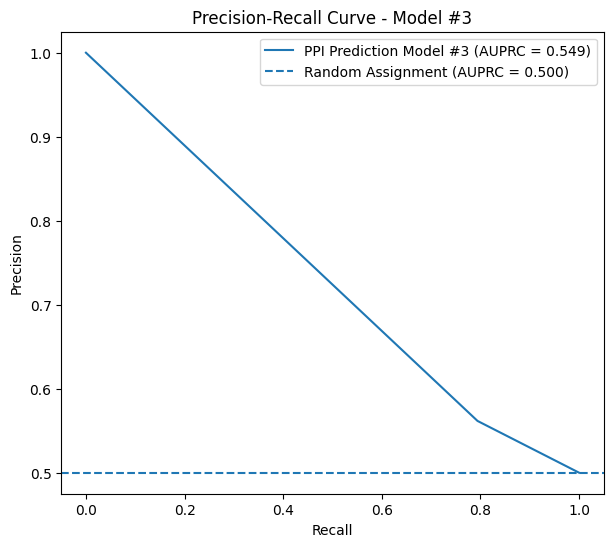

In [88]:
# Calculate precision-recall curve (with scaling)
precision, recall, thresholds = precision_recall_curve(y_test, y_prob_small)

# Calculate AUPRC
auprc = average_precision_score(y_test, y_prob_small)

# Plot
plt.figure(figsize=(7, 6))

plt.plot(
    recall,
    precision,
    label=f'PPI Prediction Model #3 (AUPRC = {auprc:.3f})'
)

# Baseline for a balanced test set
baseline = y_test.mean()
plt.axhline(
    baseline,
    linestyle='--',
    label=f'Random Assignment (AUPRC = {baseline:.3f})'
)

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve - Model #3')
plt.legend()
plt.show()

In [89]:
thresholds = np.arange(0.01, 1.00, 0.01)

f1_scores = []

for threshold in thresholds:
    y_pred_small = (y_prob_small >= threshold).astype(int)
    f1_scores.append(f1_score(y_test_small, y_pred_small))

best_idx = np.argmax(f1_scores)

best_threshold = thresholds[best_idx]
best_f1_small = f1_scores[best_idx]

print('Best threshold:', best_threshold)
print('Best F1:', best_f1_small)

Best threshold: 0.01
Best F1: 0.6579110908563616


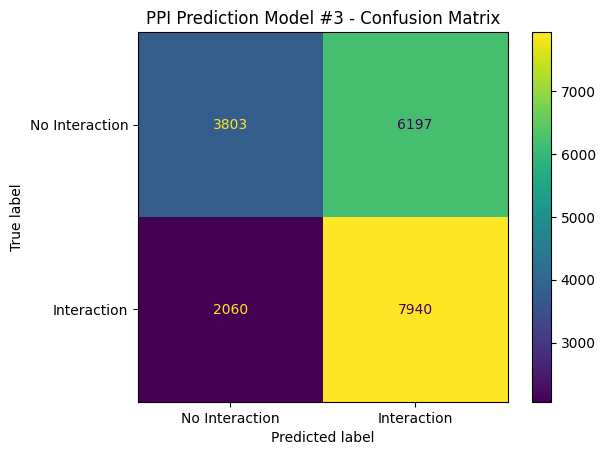

In [90]:
# Create a confusion matrix
# Convert probabilities to 0/1 predictions
y_pred_small = (y_prob_small >= 0.5).astype(int)

# Create confusion matrix
cm = confusion_matrix(y_test, y_pred_small)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['No Interaction', 'Interaction']
)

disp.plot()
plt.title('PPI Prediction Model #3 - Confusion Matrix')
plt.show()

### Now we compare all 3 models:

In [91]:
# Compile the results dictionaries and display in a table
results_small.pop('loss', None)
results1.pop('loss', None)
results2.pop('loss', None)

results_small.pop('auc', None)
results1.pop('auc', None)
results2.pop('auc', None)

results_small['f1 Score'] = f1_small
results1['f1 Score'] = f1_1
results2['f1 Score'] = f1_2

results_small['ROC-AUC'] = roc_auc_small
results1['ROC-AUC'] = roc_auc1
results2['ROC-AUC'] = roc_auc2

results_small['PR-AUC'] = APS_small
results1['PR-AUC'] = APS1
results2['PR-AUC'] = APS2

comparison = pd.DataFrame({
    'ESM2-640 (w/ Scaling)': results_small,
    'ESM2-1280 (No Scaling)': results1,
    'ESM2-1280 (w/ Scaling)': results2
})

display(comparison)

,ESM2-640 (w/ Scaling),ESM2-1280 (No Scaling),ESM2-1280 (w/ Scaling)
accuracy,0.587150,0.5002,0.596750
precision,0.561647,1.0000,0.574475
recall,0.794000,0.0004,0.746300
f1 Score,0.657911,0.0008,0.649211
ROC-AUC,0.587150,0.5006,0.596750
PR-AUC,0.548948,0.5006,0.555580
